# Preprocesing

## Importing Libraries

In [1]:
! pip install tensorflow-addons


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import math
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import zscore
from sklearn.utils import shuffle, resample, class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.layers import (
    Input, InputLayer, Conv2D, MaxPooling2D, MaxPool2D, BatchNormalization,
    GlobalAveragePooling2D, Flatten, Dense, Dropout
)
from tensorflow.keras.regularizers import l2


In [3]:
# CONFIG
IMG_SIZE = (96, 96)
BENIGN_TYPES    = ['df', 'bkl', 'vasc', 'nv']
MALIGNANT_TYPES = ['bcc', 'mel', 'akiec']
LABEL_MAP = {'Benign': 0, 'Malignant': 1}
IMG_DIR = Path(r"C:\Users\LENOVO\OneDrive - Asia Pacific University\Desktop\Assinments APU\sem3\project\Project_AI\HAM10000_images")
df = pd.read_csv("HAM10000_metadata.csv")  # contains columns “image_id”, “dx”, etc.

# 1.1 Create a “diagnosis_group” column of strings "Benign"/"Malignant"
df['diagnosis_group'] = df['dx'].apply(
    lambda x: 'Benign' if x in BENIGN_TYPES else ('Malignant' if x in MALIGNANT_TYPES else np.nan)
)
df = df.dropna(subset=['diagnosis_group']).reset_index(drop=True)

# 1.2 Split into benign vs malignant
df_benign = df[df['diagnosis_group']=='Benign']
df_malig  = df[df['diagnosis_group']=='Malignant']


df_ben_half = df_benign.sample(frac=0.5, random_state=42)
print("After partial undersampling:", df_ben_half['diagnosis_group'].value_counts().to_dict())

# 1.4 Oversample malignant to match full benign count
from sklearn.utils import resample

df_mal_upsampled = resample(df_malig,
                            replace=True,
                            n_samples=len(df_benign),
                            random_state=42)
print("After oversampling malignant:", df_mal_upsampled['diagnosis_group'].value_counts().to_dict())

# 1.5 Combine into final balanced dataset
df_bal = pd.concat([df_benign, df_mal_upsampled]).reset_index(drop=True)


# 1.4 Attach full filepaths
all_paths = list(IMG_DIR.rglob("*.jpg"))
id2path = {p.stem: p for p in all_paths}
df_bal['path'] = df_bal['image_id'].map(id2path)
df_bal = df_bal.dropna(subset=['path']).reset_index(drop=True)

# 1.5 Map “Benign”→0, “Malignant”→1
df_bal['label'] = df_bal['diagnosis_group'].map(LABEL_MAP)

print(f"Balanced dataset size: {len(df_bal)}  (should be 3,908)")

After partial undersampling: {'Benign': 4030}
After oversampling malignant: {'Malignant': 8061}
Balanced dataset size: 16122  (should be 3,908)


Final class balance (label counts):
label
0    8061
1    8061
Name: count, dtype: int64


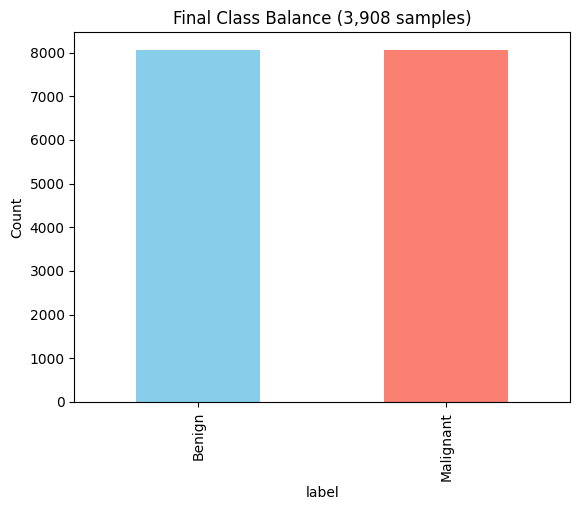

In [4]:
print("Final class balance (label counts):")
print(df_bal['label'].value_counts())

# Optional: Plot a bar chart
df_bal['label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0,1], ['Benign', 'Malignant'])
plt.title("Final Class Balance (3,908 samples)")
plt.ylabel("Count")
plt.show()


In [5]:
# Data generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    rescale=1./255
)

# Load original color images
def load_images(indexes):
    images, labels = [], []
    for idx in indexes:
        img_bgr = cv2.imread(df_bal.loc[idx, "path"])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, IMG_SIZE)
        images.append(img_resized)
        labels.append(df_bal.loc[idx, "label"])
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

# Train/val/test split
train_idx, test_idx = train_test_split(df_bal.index, test_size=0.3, stratify=df_bal['label'], random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, stratify=df_bal.loc[train_idx, 'label'], random_state=42)
X_train, y_train = load_images(train_idx)
X_val, y_val = load_images(val_idx)
X_test, y_test = load_images(test_idx)


In [6]:
# Check class balance in train, validation, and test
print("Train class balance:")
print(pd.Series(y_train).value_counts())

print("\nValidation class balance:")
print(pd.Series(y_val).value_counts())

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())


Train class balance:
1    4514
0    4514
Name: count, dtype: int64

Validation class balance:
1    1129
0    1128
Name: count, dtype: int64

Test class balance:
0    2419
1    2418
Name: count, dtype: int64


# Building Model

# CNN

Image size 64

## Tuning 1

In [ ]:
# Define CNN
cnn_model = Sequential([
    InputLayer(input_shape=(64, 64, 3)),

    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,225 (2.61 MB)

 Trainable params: 683,777 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, patience=3, min_lr=1e-6)

history = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 529ms/step - accuracy: 0.6774 - loss: 0.7869 - val_accuracy: 0.5002 - val_loss: 0.7637 - learning_rate: 0.0010
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 43s 602ms/step - accuracy: 0.7397 - loss: 0.5240 - val_accuracy: 0.5321 - val_loss: 0.6756 - learning_rate: 0.0010
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 62s 862ms/step - accuracy: 0.7514 - loss: 0.4806 - val_accuracy: 0.5981 - val_loss: 0.6633 - learning_rate: 0.0010
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7782 - loss: 0.4649 - val_accuracy: 0.7147 - val_loss: 0.5449 - learning_rate: 0.0010
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 208s 3s/step - accuracy: 0.7907 - loss: 0.4317 - val_accuracy: 0.6159 - val_loss: 0.7393 - learning_rate: 0.0010
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.7831 - loss: 0.4443 - val_accuracy: 0.7226 - val_loss: 0.4972 - learning_rate: 0.0010
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.7938 - loss: 0.4270 - v

In [9]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best Epoch: 10
Training Accuracy: 0.8085
Validation Accuracy: 0.8051
Training Loss: 0.4020
Validation Loss: 0.4057


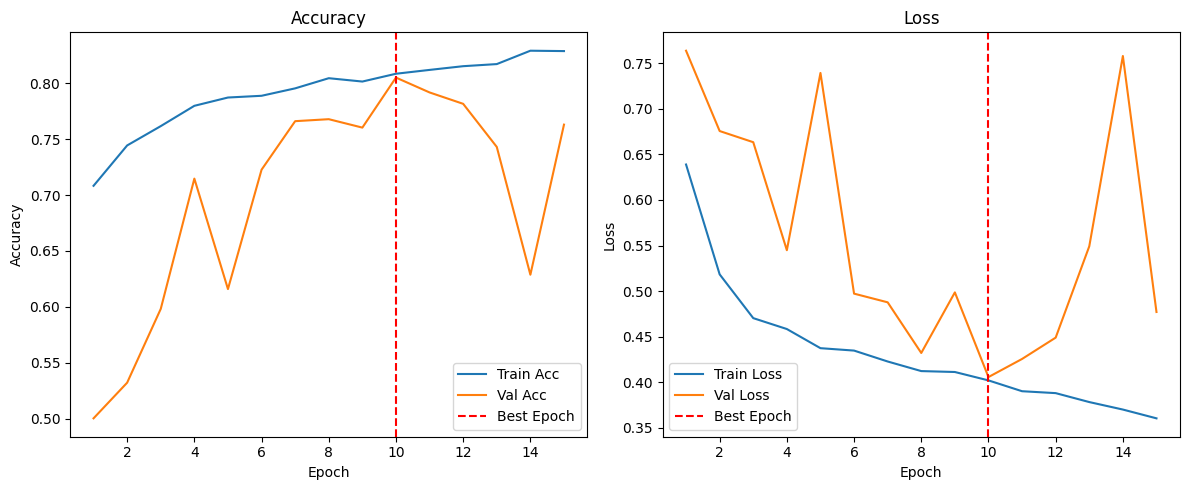

In [10]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
# Evaluate loss and accuracy
test_loss, test_accuracy = cnn_model.evaluate(X_test / 255.0, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")



Test Accuracy: 0.7974
Test Loss: 0.4107


In [12]:
# Predict
y_pred_probs = cnn_model.predict(X_test / 255.0, verbose=0)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))



Confusion Matrix:
[[1680  739]
 [ 241 2177]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.87      0.69      0.77      2419
   Malignant       0.75      0.90      0.82      2418

    accuracy                           0.80      4837
   macro avg       0.81      0.80      0.80      4837
weighted avg       0.81      0.80      0.80      4837



## Adding layers 

In [ ]:
# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3), padding='same'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Flatten(),
    Dropout(0.4),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,185 (2.64 MB)

 Trainable params: 692,353 (2.64 MB)

 Non-trainable params: 832 (3.25 KB)

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=10, 
    restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, 
    patience=5, min_lr=1e-6)

# Train
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.4890 - loss: 1.0184 - val_accuracy: 0.5002 - val_loss: 0.7306 - learning_rate: 1.0000e-05
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.5839 - loss: 0.8373 - val_accuracy: 0.5117 - val_loss: 0.7211 - learning_rate: 1.0000e-05
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.6209 - loss: 0.7801 - val_accuracy: 0.6624 - val_loss: 0.7014 - learning_rate: 1.0000e-05
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.6410 - loss: 0.7408 - val_accuracy: 0.6646 - val_loss: 0.6762 - learning_rate: 1.0000e-05
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.6435 - loss: 0.7390 - val_accuracy: 0.6761 - val_loss: 0.6458 - learning_rate: 1.0000e-05
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 305s 4s/step - accuracy: 0.6579 - loss: 0.7176 - val_accuracy: 0.6819 - val_loss: 0.6118 - learning_rate: 1.0000e-05
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0

In [9]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best Epoch: 69
Training Accuracy: 0.7647
Validation Accuracy: 0.8135
Training Loss: 0.5079
Validation Loss: 0.4431


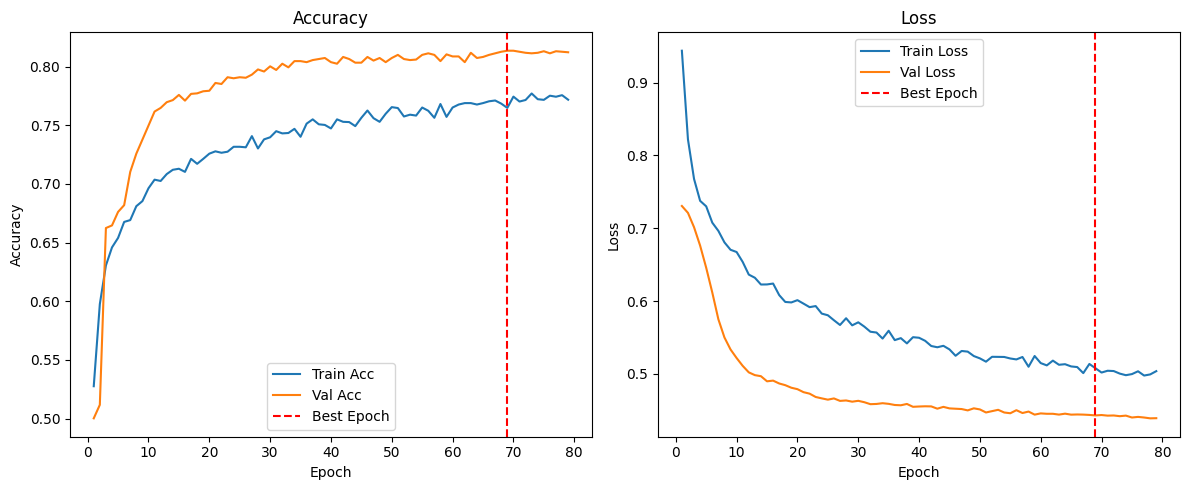

In [10]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)


152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7951 - loss: 0.4643
Test accuracy: 0.80173659324646
Test loss:  0.45161759853363037


In [12]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > 0.5).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step
Confusion Matrix:
 [[1853  566]
 [ 393 2025]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.77      0.79      2419
           1       0.78      0.84      0.81      2418

    accuracy                           0.80      4837
   macro avg       0.80      0.80      0.80      4837
weighted avg       0.80      0.80      0.80      4837



## learning rate of 1e-4

In [ ]:
# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3), padding='same'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Flatten(),
    Dropout(0.4),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,185 (2.64 MB)

 Trainable params: 692,353 (2.64 MB)

 Non-trainable params: 832 (3.25 KB)

In [14]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 776ms/step - accuracy: 0.6056 - loss: 0.8489 - val_accuracy: 0.5144 - val_loss: 0.7209 - learning_rate: 1.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 53s 748ms/step - accuracy: 0.6989 - loss: 0.6658 - val_accuracy: 0.4998 - val_loss: 0.7454 - learning_rate: 1.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 84s 768ms/step - accuracy: 0.7167 - loss: 0.6166 - val_accuracy: 0.4998 - val_loss: 0.8853 - learning_rate: 1.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 55s 769ms/step - accuracy: 0.7345 - loss: 0.5916 - val_accuracy: 0.5007 - val_loss: 0.8785 - learning_rate: 1.0000e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 54s 762ms/step - accuracy: 0.7432 - loss: 0.5649 - val_accuracy: 0.5126 - val_loss: 0.8350 - learning_rate: 1.0000e-04
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 55s 767ms/step - accuracy: 0.7477 - loss: 0.5520 - val_accuracy: 0.5764 - val_loss: 0.7036 - learning_rate: 1.0000e-04
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 54s 761ms/ste

In [15]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best Epoch: 31
Training Accuracy: 0.8006
Validation Accuracy: 0.8343
Training Loss: 0.4472
Validation Loss: 0.4077


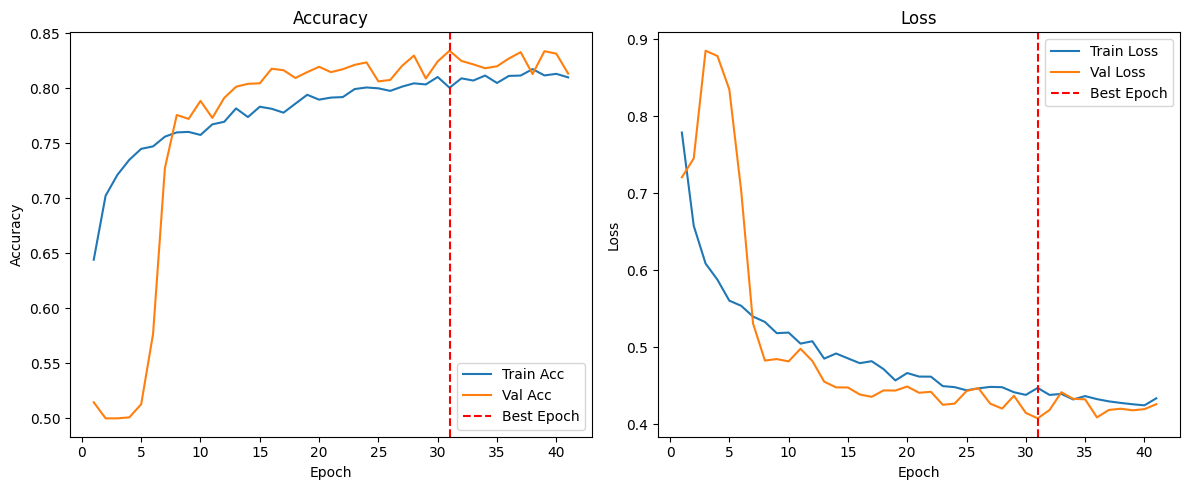

In [16]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)


152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8166 - loss: 0.4211
Test accuracy: 0.8207566738128662
Test loss:  0.412314236164093


In [18]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > 0.5).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step
Confusion Matrix:
 [[1799  620]
 [ 247 2171]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.74      0.81      2419
           1       0.78      0.90      0.83      2418

    accuracy                           0.82      4837
   macro avg       0.83      0.82      0.82      4837
weighted avg       0.83      0.82      0.82      4837



## Reduced dropout + lr = 2e-4 + Extra conv layer for capacity

In [19]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3), padding='same'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(256, (3,3), activation='relu'),  # added extra conv layer
    BatchNormalization(),
    MaxPool2D(2,2),

    Flatten(),
    Dropout(0.3),  # reduced dropout

    Dense(128, activation='relu', kernel_regularizer=l2(0.00005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(0.00005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(1e-4),  # slightly higher learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,625 (2.02 MB)

 Trainable params: 529,281 (2.02 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [20]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6203 - loss: 0.7940 - val_accuracy: 0.4998 - val_loss: 0.7037 - learning_rate: 1.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 816ms/step - accuracy: 0.7206 - loss: 0.6050 - val_accuracy: 0.4998 - val_loss: 0.7305 - learning_rate: 1.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 858ms/step - accuracy: 0.7371 - loss: 0.5601 - val_accuracy: 0.4998 - val_loss: 0.8094 - learning_rate: 1.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 63s 889ms/step - accuracy: 0.7444 - loss: 0.5509 - val_accuracy: 0.5915 - val_loss: 0.7043 - learning_rate: 1.0000e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 903ms/step - accuracy: 0.7628 - loss: 0.5217 - val_accuracy: 0.6221 - val_loss: 0.6559 - learning_rate: 1.0000e-04
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 916ms/step - accuracy: 0.7623 - loss: 0.5160 - val_accuracy: 0.6376 - val_loss: 0.6747 - learning_rate: 1.0000e-04
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 83s 926ms/step -

In [21]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best Epoch: 28
Training Accuracy: 0.8217
Validation Accuracy: 0.8445
Training Loss: 0.4024
Validation Loss: 0.3817


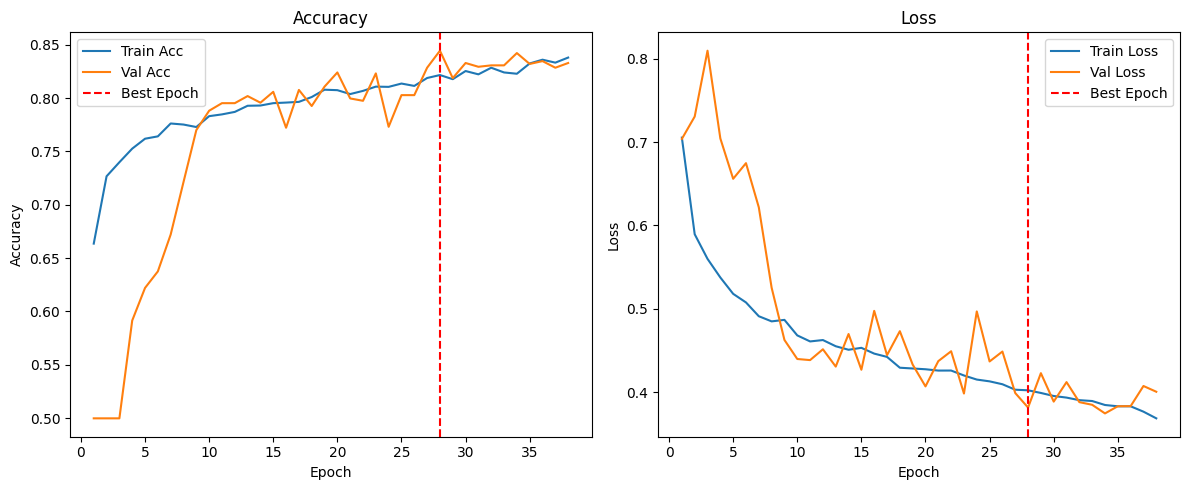

In [22]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)


152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8291 - loss: 0.3988
Test accuracy: 0.8304734230041504
Test loss:  0.38867706060409546


In [24]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > 0.5).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step
Confusion Matrix:
 [[1896  523]
 [ 297 2121]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.78      0.82      2419
           1       0.80      0.88      0.84      2418

    accuracy                           0.83      4837
   macro avg       0.83      0.83      0.83      4837
weighted avg       0.83      0.83      0.83      4837



In [ ]:
model.save('best_cnn_model.h5')

In [ ]:
from tensorflow.keras.models import load_model
best_model = load_model('best_cnn_model.h5')

In [ ]:
model.save('best_cnn_model.keras')

In [ ]:
from tensorflow import keras

best_model = keras.models.load_model('best_cnn_model.keras')

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 28 variables whereas the saved optimizer has 54 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Input size 96

In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3), padding='same'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(256, (3,3), activation='relu'),  # added extra conv layer
    BatchNormalization(),
    MaxPool2D(2,2),

    Flatten(),
    Dropout(0.3),  # reduced dropout

    Dense(128, activation='relu', kernel_regularizer=l2(0.00005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(0.00005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(1e-4),  # slightly higher learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,841 (3.52 MB)

 Trainable params: 922,497 (3.52 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [8]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.6628 - loss: 0.7264 - val_accuracy: 0.4998 - val_loss: 0.7897 - learning_rate: 1.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7488 - loss: 0.5495 - val_accuracy: 0.4998 - val_loss: 1.0279 - learning_rate: 1.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.7555 - loss: 0.5270 - val_accuracy: 0.4998 - val_loss: 1.1301 - learning_rate: 1.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.7619 - loss: 0.5096 - val_accuracy: 0.4998 - val_loss: 1.1621 - learning_rate: 1.0000e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.7789 - loss: 0.4821 - val_accuracy: 0.4998 - val_loss: 1.1073 - learning_rate: 1.0000e-04
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7852 - loss: 0.4769 - val_accuracy: 0.5304 - val_loss: 0.9304 - learning_rate: 1.0000e-04
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 

In [13]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best Epoch: 23
Training Accuracy: 0.8209
Validation Accuracy: 0.8409
Training Loss: 0.4030
Validation Loss: 0.3886


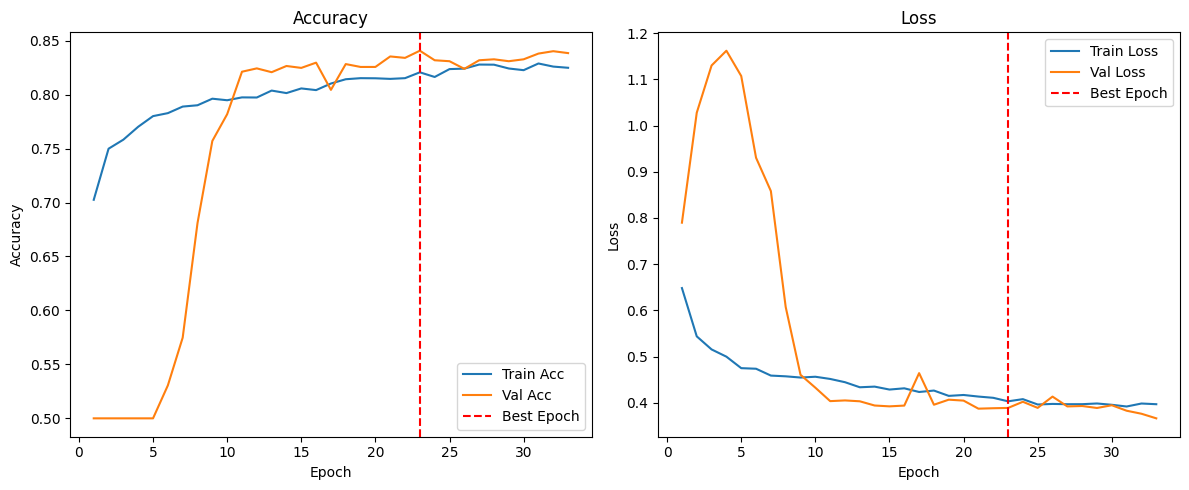

In [14]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [15]:
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)


152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.8290 - loss: 0.3984
Test accuracy: 0.8323341012001038
Test loss:  0.3885236084461212


In [16]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > 0.5).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

152/152 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step
Confusion Matrix:
 [[1828  591]
 [ 220 2198]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      2419
           1       0.79      0.91      0.84      2418

    accuracy                           0.83      4837
   macro avg       0.84      0.83      0.83      4837
weighted avg       0.84      0.83      0.83      4837



## Increasing input sizes to 96 (Best performannce)

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3), padding='same'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Flatten(),
    Dropout(0.3),  # reduced dropout

    Dense(128, activation='relu', kernel_regularizer=l2(0.00005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(0.00005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(5e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,841 (3.52 MB)

 Trainable params: 922,497 (3.52 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [18]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_val / 255.0, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.6229 - loss: 0.8043 - val_accuracy: 0.4998 - val_loss: 0.7642 - learning_rate: 5.0000e-05
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7313 - loss: 0.5800 - val_accuracy: 0.4998 - val_loss: 0.9300 - learning_rate: 5.0000e-05
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7441 - loss: 0.5686 - val_accuracy: 0.4998 - val_loss: 0.8306 - learning_rate: 5.0000e-05
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7552 - loss: 0.5465 - val_accuracy: 0.5073 - val_loss: 0.7758 - learning_rate: 5.0000e-05
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.7664 - loss: 0.5225 - val_accuracy: 0.5919 - val_loss: 0.6595 - learning_rate: 5.0000e-05
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7591 - loss: 0.5234 - val_accuracy: 0.7067 - val_loss: 0.5250 - learning_rate: 5.0000e-05
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7709

In [24]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {history.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print(f"Training Loss: {history.history['loss'][best_epoch-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][best_epoch-1]:.4f}")

Best Epoch: 33
Training Accuracy: 0.8158
Validation Accuracy: 0.8485
Training Loss: 0.4033
Validation Loss: 0.3807


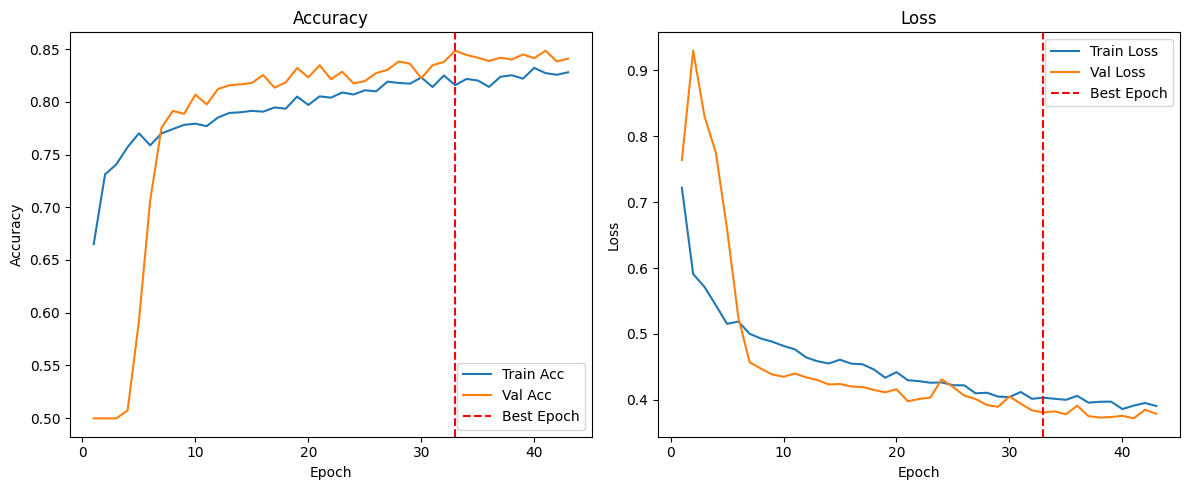

In [25]:
epochs = range(1, len(history.history['accuracy']) + 1)

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.axvline(best_epoch, color='r', linestyle='--', label='Best Epoch')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [26]:
test_loss, test_acc = model.evaluate(X_test / 255.0, y_test)
print("Test accuracy:", test_acc)
print("Test loss: ", test_loss)


152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.8305 - loss: 0.3910
Test accuracy: 0.8319206237792969
Test loss:  0.38462451100349426


In [27]:
# Confusion matrix & classification report
y_pred = (model.predict(X_test / 255.0) > 0.5).astype("int32").flatten()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step
Confusion Matrix:
 [[1857  562]
 [ 251 2167]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      2419
           1       0.79      0.90      0.84      2418

    accuracy                           0.83      4837
   macro avg       0.84      0.83      0.83      4837
weighted avg       0.84      0.83      0.83      4837



In [23]:
#model.save('best_cnn_96_model.keras')